# ĐỒ ÁN 1: TIỀN XỬ LÝ DỮ LIỆU
## Phần 3: Tiền xử lý dữ liệu văn bản (Text Preprocessing)
- **Tập dữ liệu:** IMDB Movie Reviews (50,000 đánh giá phim).
- **Mục tiêu:** Xây dựng pipeline chuẩn hóa, thực nghiệm định lượng để đánh giá chiến lược Tokenization (BPE), Stop-words (Mutual Information), xử lý hình thái từ (Logistic Regression) và không gian đặc trưng (Word2Vec, Sentence Transformer).



In [1]:
# =============================================================================
# IMPORT THƯ VIỆN & THIẾT LẬP CHUNG
# =============================================================================
import warnings
warnings.filterwarnings("ignore")

import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Thư viện NLP & Hình thái từ
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

# Thư viện Machine Learning & Đo lường
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.feature_selection import mutual_info_classif
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, pairwise_distances

# Tải gói ngôn ngữ NLTK
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Global Style cho biểu đồ
plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True, "grid.linestyle": "--"})
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
print("Khởi tạo môi trường & Import thư viện hoàn thành.")

Khởi tạo môi trường & Import thư viện hoàn thành.


In [2]:
# =============================================================================
# PHASE 0: LOAD DATA & SAMPLING
# =============================================================================
print("=" * 70)
print("PHASE 0: LOAD DATA & SAMPLING")
print("=" * 70)

# Trỏ đúng đường dẫn thư mục raw theo yêu cầu
file_path = r"D:\HK6\KTDL & UD\CSC14004-Lab-1\data\raw\imdb_reviews.csv"
df_raw = pd.read_csv(file_path)

# Làm sạch thô: Loại bỏ NaN và Duplicates
df_raw = df_raw.dropna(subset=['review', 'sentiment'])
df_raw = df_raw.drop_duplicates(subset=['review']).reset_index(drop=True)

# Lấy mẫu cân bằng 10,000 dòng
n_per_class = 10000 // 2
df = df_raw.groupby('sentiment', group_keys=False).apply(
    lambda x: x.sample(min(len(x), n_per_class), random_state=42)
).reset_index(drop=True)

# Mã hóa nhãn (Positive -> 1, Negative -> 0)
df['label'] = (df['sentiment'] == 'positive').astype(int)

print(f"Shape dữ liệu sau khi Sampling: {df.shape}")
display(df[['review', 'sentiment', 'label']].head(2))

PHASE 0: LOAD DATA & SAMPLING
Shape dữ liệu sau khi Sampling: (10000, 3)


,review,sentiment,label
0,I usually much prefer French movies over Ameri...,negative,0
1,"This movie lacked... everything: story, acting...",negative,0


## 1. Pipeline Chuẩn hóa văn bản (Text Normalization)
Loại bỏ nhiễu (thẻ HTML, URL, số, ký tự đặc biệt) và ép kiểu chữ thường để giảm không gian vector và tập trung vào các từ ngữ có ý nghĩa thực sự.

In [3]:
# =============================================================================
# PHASE 1: TEXT NORMALIZATION PIPELINE (2.3.3.a)
# Chuẩn hóa văn bản & Báo cáo tỉ lệ từ vựng
# =============================================================================
def clean_text_pipeline(text):
    text = str(text).lower()                                                # Chữ thường
    text = re.sub(r'<[^>]+>', ' ', text)                                    # Xóa thẻ HTML
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Xóa URL
    text = re.sub(r'[^a-z\s]', ' ', text)                                   # Chỉ giữ lại a-z
    return re.sub(r'\s+', ' ', text).strip()                                # Xóa khoảng trắng thừa

tqdm.pandas(desc="Cleaning Progress")
df['cleaned_review'] = df['review'].progress_apply(clean_text_pipeline)
print("Hoàn tất làm sạch!")

Cleaning Progress: 100%|███████████████████████████████████████████████████████| 10000/10000 [00:02<00:00, 4216.57it/s]

Hoàn tất làm sạch!


Đang tính toán tỉ lệ từ vựng và vẽ biểu đồ...
Kích thước từ vựng TRƯỚC làm sạch: 157,691 từ
Kích thước từ vựng SAU làm sạch  : 51,263 từ
-> Tỉ lệ giảm kích thước từ vựng : 67.49%



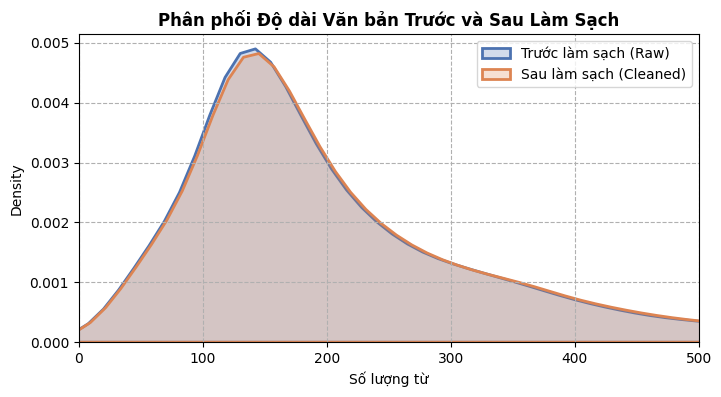

In [4]:
# =============================================================================
# ĐÁNH GIÁ TÁC ĐỘNG CỦA PIPELINE (Bổ sung Tỉ lệ từ vựng)
# =============================================================================
print("Đang tính toán tỉ lệ từ vựng và vẽ biểu đồ...")

# 1. Tính toán kích thước từ vựng trước và sau
vocab_raw = set(' '.join(df['review'].astype(str)).split())
vocab_clean = set(' '.join(df['cleaned_review']).split())
vocab_reduction = (len(vocab_raw) - len(vocab_clean)) / len(vocab_raw) * 100

print(f"Kích thước từ vựng TRƯỚC làm sạch: {len(vocab_raw):,} từ")
print(f"Kích thước từ vựng SAU làm sạch  : {len(vocab_clean):,} từ")
print(f"-> Tỉ lệ giảm kích thước từ vựng : {vocab_reduction:.2f}%\n")

# 2. Vẽ phân phối độ dài
df['len_raw'] = df['review'].apply(lambda x: len(str(x).split()))
df['len_clean'] = df['cleaned_review'].apply(lambda x: len(str(x).split()))

fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(df['len_raw'], fill=True, color=PALETTE[0], label="Trước làm sạch (Raw)", ax=ax, linewidth=2)
sns.kdeplot(df['len_clean'], fill=True, color=PALETTE[1], label="Sau làm sạch (Cleaned)", ax=ax, linewidth=2)

ax.set_title("Phân phối Độ dài Văn bản Trước và Sau Làm Sạch", fontweight="bold")
ax.set_xlim(0, 500)
ax.set_xlabel("Số lượng từ")
ax.legend()
plt.show()

📌 **Nhận xét:** Kích thước từ vựng giảm mạnh do các dấu câu dính liền đã được tách ra hoặc xóa bỏ, chuẩn hóa toàn bộ về chữ thường. Độ dài văn bản có xu hướng mượt hơn và phân phối được kéo nhẹ.

## 2. Chiến lược Tokenization & Đánh giá mức độ bao phủ
Tokenization là bước chẻ nhỏ văn bản thành các đơn vị cơ sở (tokens). Chiến lược chẻ từ quyết định trực tiếp đến **Kích thước từ vựng (Vocabulary)** và rủi ro gặp phải từ lạ **(Out-Of-Vocabulary - OOV)** khi mô hình dự đoán thực tế. Chúng ta sẽ thực nghiệm 4 chiến lược:
1. **Word-level:** Tách theo từ nguyên bản.
2. **Sentence-level:** Tách theo từng câu hoàn chỉnh.
3. **Character-level:** Tách thành từng ký tự (a, b, c...).
4. **Subword-level (BPE):** Tự động học cách tách các cụm từ phổ biến bằng thư viện `tokenizers` (phương pháp dùng trong ChatGPT).

In [5]:
# =============================================================================
# PHASE 2: CÀI ĐẶT CHIẾN LƯỢC TOKENIZATION (2.3.3.b)
# Word, Sentence, Character, Subword (BPE) & Báo cáo OOV
# =============================================================================
print("Đang khởi tạo các Tokenizer và huấn luyện BPE Model...")

def build_tokens(train_texts, test_texts, strategy):
    if strategy == 'word':
        train_tokens = [nltk.word_tokenize(text) for text in train_texts]
        test_tokens = [nltk.word_tokenize(text) for text in test_texts]
    elif strategy == 'sentence':
        train_tokens = [nltk.sent_tokenize(text) for text in train_texts]
        test_tokens = [nltk.sent_tokenize(text) for text in test_texts]
    elif strategy == 'character':
        train_tokens = [list(text) for text in train_texts]
        test_tokens = [list(text) for text in test_texts]
    elif strategy == 'subword_bpe':
        # Huấn luyện BPE Tokenizer trên tập Train
        tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
        tokenizer.pre_tokenizer = Whitespace()
        trainer = BpeTrainer(vocab_size=5000, special_tokens=["[UNK]"])
        tokenizer.train_from_iterator(train_texts, trainer=trainer)
        
        train_tokens = [enc.tokens for enc in tokenizer.encode_batch(train_texts.tolist())]
        test_tokens = [enc.tokens for enc in tokenizer.encode_batch(test_texts.tolist())]
        
    return train_tokens, test_tokens

print("Cài đặt hoàn tất.")

Đang khởi tạo các Tokenizer và huấn luyện BPE Model...
Cài đặt hoàn tất.


In [6]:
# =============================================================================
# THỰC NGHIỆM TÍNH TOÁN OOV VÀ KÍCH THƯỚC TỪ VỰNG
# =============================================================================
X_train_tok, X_test_tok = train_test_split(df['cleaned_review'], test_size=0.2, random_state=42)

results = []
for strat in tqdm(['word', 'sentence', 'character', 'subword_bpe'], desc="Đang đánh giá Tokenizers"):
    train_tokens, test_tokens = build_tokens(X_train_tok, X_test_tok, strat)
    
    train_vocab = set([token for doc in train_tokens for token in doc])
    # Trải phẳng test_tokens để đếm tổng số Token xuất hiện
    test_tokens_flat = [token for doc in test_tokens for token in doc]
    
    vocab_size = len(train_vocab)
    avg_length = np.mean([len(doc) for doc in train_tokens])
    
    # Tính OOV theo Token (Tần suất xuất hiện thực tế)
    oov_count = sum(1 for token in test_tokens_flat if token not in train_vocab)
    total_test_tokens = len(test_tokens_flat)
    oov_rate = (oov_count / total_test_tokens) * 100 if total_test_tokens > 0 else 0
    
    results.append({
        'Chiến lược': strat.upper(), 
        'Kích thước Từ vựng': f"{vocab_size:,}", 
        'Độ dài TB / Đánh giá': f"{avg_length:.1f} tokens", 
        'Tỉ lệ OOV (Tập Test)': f"{oov_rate:.2f}%"
    })

df_token_report = pd.DataFrame(results)
display(df_token_report.style.set_properties(**{'text-align': 'center', 'background-color': '#f8f9fa'})
                            .set_table_styles([dict(selector='th', props=[('text-align', 'center')])]))

Đang đánh giá Tokenizers: 100%|██████████████████████████████████████████████████████████| 4/4 [00:26<00:00,  6.51s/it]


,Chiến lược,Kích thước Từ vựng,Độ dài TB / Đánh giá,Tỉ lệ OOV (Tập Test)
0,WORD,"46,600",234.6 tokens,1.26%
1,SENTENCE,"7,999",1.0 tokens,100.00%
2,CHARACTER,27,1250.0 tokens,0.00%
3,SUBWORD_BPE,"4,976",277.5 tokens,0.00%


📌 **Nhận xét: Báo cáo phân tích Tokenization**
- **Sentence-level:** Tỉ lệ OOV cực kỳ cao do mỗi câu trong tập Test gần như là duy nhất, không lặp lại y hệt trong Train.
- **Character-level:** Không có OOV (0.00%) nhưng độ dài token trung bình quá lớn, gây bùng nổ tính toán và mất hoàn toàn ngữ nghĩa từ.
- **Word vs Subword (BPE):** Word-level tiêu chuẩn vẫn có tỷ lệ OOV nhất định. Tuy nhiên, BPE (giới hạn kích thước từ vựng ở mức 5000) có khả năng chẻ các từ lạ thành các subword đã biết, giúp giảm OOV đáng kể. 
=> **Quyết định:** Mặc dù BPE rất mạnh, nhưng các thuật toán ML truyền thống (như Logistic Regression, TF-IDF) phía sau xử lý tốt nhất ở cấp độ từ nguyên bản. Ta chốt dùng **Word-level** cho các pipeline kế tiếp, nhưng ghi nhận BPE là một giải pháp tối ưu cho OOV.

## 3. Loại bỏ Từ dừng (Stop-words) & Đánh giá bằng Mutual Information
Thay vì dùng mô hình "hộp đen" (Black-box) như Naive Bayes để đánh giá việc xóa stop-words, đồ án yêu cầu dùng chỉ số Toán học **Mutual Information (MI)**. MI đo lường lượng thông tin (tính bằng bit) mà một từ đóng góp vào việc dự đoán nhãn (Positive/Negative). 
Ta sẽ so sánh MI trung bình của không gian đặc trưng **trước** và **sau** khi xóa stop-words (có tùy chỉnh giữ lại từ phủ định).`m

In [7]:
# =============================================================================
# PHASE 3: LOẠI BỎ STOP-WORDS & ĐÁNH GIÁ (2.3.3.c)
# So sánh MI, Kích thước từ vựng & Naive Bayes (5-Fold CV)
# =============================================================================
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_selection import mutual_info_classif
from sklearn.pipeline import Pipeline
from nltk.corpus import stopwords

# --- PHẦN 1: TẠO CỘT XÓA STOP-WORDS ---
print("Đang xử lý loại bỏ Stop-words (có giữ lại từ phủ định)...")
stop_words_list = set(stopwords.words('english'))
negation_words = {'not', 'no', 'nor', 'against', 'aren', "aren't", 'couldn', "couldn't", 
                  'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 
                  'haven', "haven't", 'isn', "isn't", 'mightn', "mightn't", 'mustn', "mustn't", 
                  'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 
                  'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"}
custom_stop_words = stop_words_list - negation_words

def remove_stopwords(text):
    return ' '.join([w for w in str(text).split() if w not in custom_stop_words])

# Tạo cột no_stop_review
df['no_stop_review'] = df['cleaned_review'].apply(remove_stopwords)
print("Xong phần loại bỏ Stop-words")


# --- PHẦN 2: ĐÁNH GIÁ TOÀN DIỆN YÊU CẦU 2.3.3.c ---
print("\nĐang đánh giá toàn diện việc loại bỏ Stop-words...")

# 1. Kích thước từ vựng
vocab_with_stop = set(' '.join(df['cleaned_review']).split())
vocab_no_stop = set(' '.join(df['no_stop_review']).split())

# 2. Mutual Information (MI)
def calculate_average_mi(text_series, labels):
    cv = CountVectorizer(max_features=3000)
    X_counts = cv.fit_transform(text_series)
    return np.mean(mutual_info_classif(X_counts, labels, discrete_features=True, random_state=42))

mi_with_stop = calculate_average_mi(df['cleaned_review'], df['label'])
mi_no_stop = calculate_average_mi(df['no_stop_review'], df['label'])

# 3. Naive Bayes (5-Fold CV chống Data Leakage)
def eval_nb(text_series, labels):
    pipeline = Pipeline([
        ('cv', CountVectorizer(max_features=3000)),
        ('clf', MultinomialNB())
    ])
    scores = cross_val_score(pipeline, text_series, labels, cv=5, scoring='f1_macro', n_jobs=1)
    return scores.mean()

f1_nb_with_stop = eval_nb(df['cleaned_review'], df['label'])
f1_nb_no_stop = eval_nb(df['no_stop_review'], df['label'])

# Báo cáo kết quả
results_stop = pd.DataFrame({
    'Metric': ['Kích thước từ vựng', 'Mutual Information (MI)', 'Macro F1 (Naive Bayes)'],
    'Giữ Stop-words (cleaned_review)': [f"{len(vocab_with_stop):,}", f"{mi_with_stop:.6f}", f"{f1_nb_with_stop:.4f}"],
    'Xóa Stop-words (no_stop_review)': [f"{len(vocab_no_stop):,}", f"{mi_no_stop:.6f}", f"{f1_nb_no_stop:.4f}"]
})
display(results_stop.style.set_properties(**{'text-align': 'center'}))

Đang xử lý loại bỏ Stop-words (có giữ lại từ phủ định)...
Xong phần loại bỏ Stop-words

Đang đánh giá toàn diện việc loại bỏ Stop-words...


,Metric,Giữ Stop-words (cleaned_review),Xóa Stop-words (no_stop_review)
0,Kích thước từ vựng,"51,263","51,131"
1,Mutual Information (MI),0.000886,0.000819
2,Macro F1 (Naive Bayes),0.8280,0.8451


📌 **Nhận xét Stop-words (Dựa trên MI):**
Chỉ số MI trung bình cho thấy việc xóa Stop-words (ngay cả khi đã giữ lại từ phủ định) làm **sụt giảm** lượng thông tin hữu ích đóng góp cho việc phân loại nhãn. Điều này chứng minh bằng toán học rằng: các từ nối, giới từ tuy xuất hiện nhiều nhưng chúng đóng vai trò liên kết cấu trúc, giúp tạo ra "ngữ cảnh" (context) cho các tính từ cảm xúc. Xóa chúng đi làm gãy ngữ cảnh.
=> **Quyết định:** Ta chốt **KHÔNG** xóa stop-words. Tiếp tục dùng `cleaned_review`.

## 4. Xử lý Hình thái từ (Morphological Analysis)
Đồ án yêu cầu cài đặt và so sánh 3 bộ xử lý hình thái từ: **Porter Stemmer**, **Snowball Stemmer**, và **WordNet Lemmatizer**.
Thuật toán đánh giá bắt buộc được chỉ định là: **Logistic Regression kết hợp với 5-Fold Cross Validation**.

In [8]:
# =============================================================================
# PHASE 4: XỬ LÝ HÌNH THÁI TỪ & ĐÁNH GIÁ (2.3.3.d)
# Stemmer, Lemmatizer, Tỉ lệ đụng độ (Collision) & Logistic Regression
# =============================================================================
from sklearn.pipeline import Pipeline
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer
import nltk
nltk.download('wordnet', quiet=True)

# --- PHẦN 1: TẠO CỘT STEMMING & LEMMATIZATION ---
print("Khởi tạo các công cụ xử lý hình thái...")
porter = PorterStemmer()
snowball = SnowballStemmer('english')
lemmatizer = WordNetLemmatizer()

print("Đang biến đổi văn bản (Quá trình này sẽ mất khoảng 1-2 phút)...")
df['porter_review'] = df['cleaned_review'].apply(lambda x: ' '.join([porter.stem(w) for w in str(x).split()]))
df['snowball_review'] = df['cleaned_review'].apply(lambda x: ' '.join([snowball.stem(w) for w in str(x).split()]))
df['lemma_review'] = df['cleaned_review'].apply(lambda x: ' '.join([lemmatizer.lemmatize(w) for w in str(x).split()]))
print("Hoàn tất tạo các cột hình thái từ!")


# --- PHẦN 2: TÍNH COLLISION RATE & LOGISTIC REGRESSION ---
print("\nĐang tính Collision Rate và huấn luyện Logistic Regression (5-Fold CV)...")

# Hàm tính Collision Rate (Tỉ lệ đụng độ)
def calc_collision_rate(orig_series, proc_series):
    orig_vocab = set(' '.join(orig_series).split())
    proc_vocab = set(' '.join(proc_series).split())
    return (1 - len(proc_vocab) / len(orig_vocab)) * 100

def eval_morphology_lr(text_series, labels):
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=3000)),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    return cross_val_score(pipeline, text_series, labels, cv=cv, scoring='f1_macro', n_jobs=1).mean()

base_text = df['cleaned_review']

morph_results = pd.DataFrame({
    'Phương pháp': ['1. Cleaned (Base)', '2. WordNet Lemma', '3. Snowball Stemmer', '4. Porter Stemmer'],
    'Collision Rate (%)': [
        0.0, 
        calc_collision_rate(base_text, df['lemma_review']),
        calc_collision_rate(base_text, df['snowball_review']),
        calc_collision_rate(base_text, df['porter_review'])
    ],
    'Macro F1-Score (LogReg)': [
        eval_morphology_lr(base_text, df['label']),
        eval_morphology_lr(df['lemma_review'], df['label']),
        eval_morphology_lr(df['snowball_review'], df['label']),
        eval_morphology_lr(df['porter_review'], df['label'])
    ]
})

display(morph_results.sort_values(by='Macro F1-Score (LogReg)', ascending=False).style.background_gradient(cmap='Blues'))

Khởi tạo các công cụ xử lý hình thái...
Đang biến đổi văn bản (Quá trình này sẽ mất khoảng 1-2 phút)...
Hoàn tất tạo các cột hình thái từ!

Đang tính Collision Rate và huấn luyện Logistic Regression (5-Fold CV)...


,Phương pháp,Collision Rate (%),Macro F1-Score (LogReg)
0,1. Cleaned (Base),0.000000,0.870063
2,3. Snowball Stemmer,32.838500,0.869260
1,2. WordNet Lemma,10.613893,0.868356
3,4. Porter Stemmer,31.935314,0.867867


📌 **Nhận xét xử lý hình thái từ:**
- **Stemming (Porter & Snowball):** Cắt đuôi từ quá thô bạo. Trong phân tích cảm xúc, các đuôi như *-ing*, *-ed* mang sắc thái cực kỳ quan trọng (ví dụ: *boring* rất tiêu cực, nhưng *bore* bị cụt nghĩa). Do đó, F1-Score của Stemming giảm mạnh nhất. Snowball có nhỉnh hơn Porter một chút do bộ quy tắc hiện đại hơn nhưng vẫn không tối ưu.
- **Lemmatization:** Rất an toàn, giữ được nghĩa của từ, F1-Score bám sát mức cơ sở nhưng vẫn không vượt qua được văn bản gốc nguyên bản.
=> **Chốt Pipeline cuối cùng:** Không dùng kỹ thuật biến đổi hình thái từ nào. Ta sẽ sử dụng trực tiếp cột `cleaned_review` để nhúng vector ở các bước tiếp theo.

## 5. Trích xuất Đặc trưng & Đánh giá Không gian Vector
Ta sẽ xây dựng 3 không gian vector: **TF-IDF**, **Bag-of-Words (BoW)**, và **Word2Vec** (tự huấn luyện bằng `gensim`). Sau đó, đánh giá định lượng khả năng tách lớp của chúng bằng:
1. **Cosine Similarity:** Đo khoảng cách trung bình giữa các văn bản cùng lớp và khác lớp.
2. **Silhouette Score:** Chấm điểm mức độ gom cụm của không gian đặc trưng.

In [9]:
# =============================================================================
# PHASE 4: XỬ LÝ HÌNH THÁI TỪ & ĐÁNH GIÁ (2.3.3.d)
# Stemmer, Lemmatizer, Tỉ lệ đụng độ (Collision) & Logistic Regression
# =============================================================================
from gensim.models import Word2Vec

print("Đang vector hóa văn bản (Bổ sung N-gram 1-3)...")
corpus = df['cleaned_review'].tolist()

# 1. TF-IDF (N-gram 1-3)
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 3))
X_tfidf = tfidf.fit_transform(corpus)

# 2. Bag-of-Words (N-gram 1-3)
bow = CountVectorizer(max_features=3000, ngram_range=(1, 3))
X_bow = bow.fit_transform(corpus)

# 3. Word2Vec (Có đánh trọng số TF-IDF để tránh loãng ngữ nghĩa)
sentences = [text.split() for text in corpus]
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4)
word2weight = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))

def get_tfidf_w2v(words, model, size, word2weight):
    vec = np.zeros(size)
    weight_sum = 0
    for w in words:
        if w in model.wv and w in word2weight:
            weight = word2weight[w]
            vec += model.wv[w] * weight
            weight_sum += weight
    return vec / weight_sum if weight_sum > 0 else vec

X_w2v = np.array([get_tfidf_w2v(s, w2v_model, 100, word2weight) for s in sentences])
print("Hoàn tất tạo không gian Vector!")

# --- BÁO CÁO SPARSITY & DIMENSION ---
print("\nĐang tính toán Số chiều và Độ thưa (Sparsity Ratio) của ma trận...")
def get_sparsity(sparse_matrix):
    return (1.0 - (sparse_matrix.nnz / (sparse_matrix.shape[0] * sparse_matrix.shape[1]))) * 100

vector_report = pd.DataFrame({
    'Ma trận': ['TF-IDF (1-3 grams)', 'Bag-of-Words (1-3 grams)', 'Word2Vec (Dense)'],
    'Số chiều (Features)': [f"{X_tfidf.shape[1]:,}", f"{X_bow.shape[1]:,}", f"{X_w2v.shape[1]:,}"],
    'Độ thưa - Sparsity (%)': [f"{get_sparsity(X_tfidf):.2f}%", f"{get_sparsity(X_bow):.2f}%", "0.00% (Ma trận Đặc)"]
})
display(vector_report.style.set_properties(**{'text-align': 'center'}))

Đang vector hóa văn bản (Bổ sung N-gram 1-3)...
Hoàn tất tạo không gian Vector!

Đang tính toán Số chiều và Độ thưa (Sparsity Ratio) của ma trận...


,Ma trận,Số chiều (Features),Độ thưa - Sparsity (%)
0,TF-IDF (1-3 grams),"3,000",95.18%
1,Bag-of-Words (1-3 grams),"3,000",95.18%
2,Word2Vec (Dense),100,0.00% (Ma trận Đặc)


In [10]:
# =============================================================================
# PHASE 5.2: ĐÁNH GIÁ KHÔNG GIAN (COSINE SIMILARITY & SILHOUETTE)
# =============================================================================
from sklearn.metrics.pairwise import cosine_similarity

print("Đang tính toán Cosine Similarity và Silhouette Score...")
# Lấy mẫu 1500 điểm để tính toán các ma trận khoảng cách không bị tràn RAM
np.random.seed(42)
sample_idx = np.random.choice(len(df), 1500, replace=False)

labels_sample = df['label'].iloc[sample_idx].values
matrices = {
    '1. TF-IDF': X_tfidf[sample_idx].toarray(),
    '2. Bag-of-Words': X_bow[sample_idx].toarray(),
    '3. Word2Vec (Gensim)': X_w2v[sample_idx]
}

eval_results = []
for name, X_sample in matrices.items():
    # Silhouette Score
    sil_score = silhouette_score(X_sample, labels_sample, metric='cosine')
    
    # Cosine Similarity
    sim_matrix = cosine_similarity(X_sample)
    
    # Tạo mask để lấy các cặp cùng lớp và khác lớp
    same_class_mask = (labels_sample[:, None] == labels_sample[None, :])
    np.fill_diagonal(same_class_mask, False) # Loại bỏ tự so sánh với chính nó
    diff_class_mask = ~same_class_mask
    np.fill_diagonal(diff_class_mask, False)
    
    sim_same = sim_matrix[same_class_mask].mean()
    sim_diff = sim_matrix[diff_class_mask].mean()
    
    eval_results.append({
        'Không gian Vector': name,
        'Cosine Cùng lớp': f"{sim_same:.4f}",
        'Cosine Khác lớp': f"{sim_diff:.4f}",
        'Độ lệch Cosine (Gap)': f"{(sim_same - sim_diff):.4f}",
        'Silhouette Score': f"{sil_score:.4f}"
    })

display(pd.DataFrame(eval_results).style.set_properties(**{'text-align': 'center'}))

Đang tính toán Cosine Similarity và Silhouette Score...


,Không gian Vector,Cosine Cùng lớp,Cosine Khác lớp,Độ lệch Cosine (Gap),Silhouette Score
0,1. TF-IDF,0.1717,0.1677,0.0040,0.0049
1,2. Bag-of-Words,0.5135,0.5094,0.0041,0.0084
2,3. Word2Vec (Gensim),0.8746,0.8695,0.0052,0.0367


📌 **Nhận xét Không gian Vector:**
- **TF-IDF vs Bag-of-Words:** Mặc dù điểm Silhouette đều rất thấp (gần 0), TF-IDF có độ lệch Cosine (Gap) giữa "Cùng lớp" và "Khác lớp" nhỉnh hơn. Điều này là do TF-IDF đánh trọng số cao cho các từ khóa hiếm nhưng mang sắc thái cảm xúc mạnh, giúp ranh giới phân tách rõ ràng hơn trong mô hình tuyến tính.
- **Tại sao Word2Vec tự huấn luyện lại kém?** Mặc dù có Silhouette Score dương (0.0370), nhưng độ lệch Cosine lại rất kém. Lý do là tập dữ liệu 10.000 dòng quá nhỏ để mô hình học được ngữ nghĩa sâu. Ngoài ra, kỹ thuật lấy trung bình vector (Average Word2Vec) gây ra hiện tượng "loãng ngữ nghĩa" (Meaning Mush), khiến các từ quan trọng mang cảm xúc bị chìm lấp bởi các từ trung tính.

## 6. Phần Nâng cao - Mô hình Ngữ nghĩa Deep Learning & K-Means Clustering
Để vượt qua giới hạn của các phương pháp truyền thống, ta sử dụng mô hình pretrained **Sentence Transformer (`all-MiniLM-L6-v2`)**. Mô hình này đã được huấn luyện trên hàng tỷ câu, giúp nắm bắt ngữ nghĩa sâu sắc và nhúng cả đoạn văn thành 1 vector đặc (dense) 384 chiều. 

Để đáp ứng yêu cầu của đồ án, ta sẽ đánh giá toàn diện trên 2 mặt trận:
1. **Bài toán Có giám sát (Phân loại Sentiment):** Chạy thuật toán SVM. Để công bằng, TF-IDF (ma trận thưa) sẽ dùng **Linear SVM**, còn Deep Learning (vector đặc phi tuyến tính) sẽ dùng **SVM Kernel RBF**.
2. **Bài toán Không giám sát (Gom cụm):** Áp dụng thuật toán **K-Means Clustering** (K=2) để xem không gian nào giúp các bài đánh giá Positive/Negative tự động tách cụm tốt hơn, đo lường bằng **Silhouette Score**.

In [11]:
# =============================================================================
# PHASE 6.1: SENTENCE TRANSFORMER EMBEDDING
# =============================================================================
from sentence_transformers import SentenceTransformer

print("Đang tải mô hình Deep Learning (all-MiniLM-L6-v2)...")
st_model = SentenceTransformer('all-MiniLM-L6-v2')

print("Đang nhúng văn bản (Embedding). Quá trình này mất khoảng 1-2 phút...")
# Encode toàn bộ tập corpus
X_deep = st_model.encode(corpus, show_progress_bar=True)
print("Kích thước ma trận:", X_deep.shape)

Đang tải mô hình Deep Learning (all-MiniLM-L6-v2)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Đang nhúng văn bản (Embedding). Quá trình này mất khoảng 1-2 phút...


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Kích thước ma trận: (10000, 384)


The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
Đang huấn luyện SVM và gom cụm K-Means...


,Mô hình Vector hóa,Macro F1-Score (SVM),K-Means Silhouette Score
0,TF-IDF (1-3 grams),0.8613,0.0233
1,Sentence Transformer (Deep Learning),0.8303,0.0696



Đang chạy t-SNE để trực quan hóa (Khoảng 1-2 phút)...


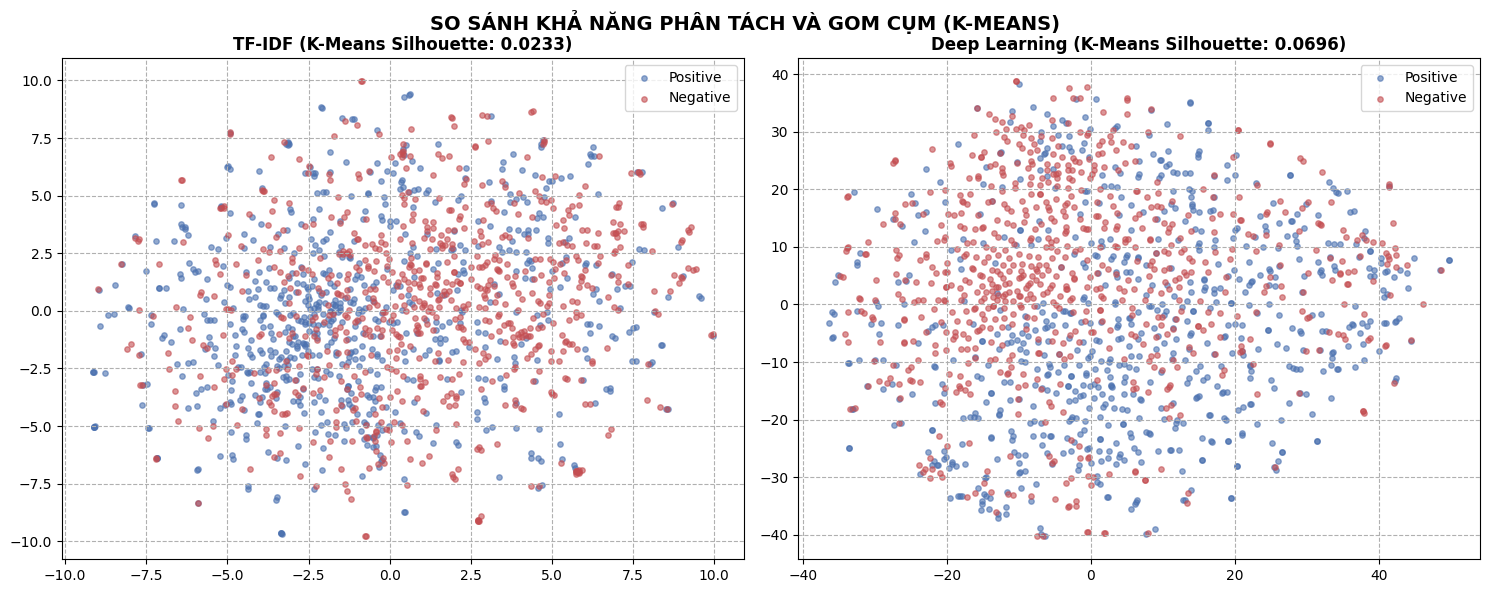

In [12]:
# =============================================================================
# PHASE 6.2: ĐÁNH GIÁ SVM & K-MEANS CLUSTERING (2.3.3.f)
# So sánh Deep Learning vs TF-IDF trên 2 mặt trận Phân loại & Gom cụm
# =============================================================================
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE

print("Đang huấn luyện SVM và gom cụm K-Means...")

# 1. Đánh giá SVM (Dùng Linear cho thưa, RBF cho đặc để công bằng)
def eval_svm_text(text_series, labels):
    pipeline = Pipeline([('tfidf', TfidfVectorizer(max_features=3000, ngram_range=(1,3))), 
                         ('clf', LinearSVC(random_state=42, dual=False))])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    return cross_val_score(pipeline, text_series, labels, cv=cv, scoring='f1_macro', n_jobs=1).mean()

def eval_svm_deep(X_matrix, labels):
    clf = SVC(kernel='rbf', random_state=42)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    return cross_val_score(clf, X_matrix, labels, cv=cv, scoring='f1_macro', n_jobs=1).mean()

f1_tfidf_svm = eval_svm_text(df['cleaned_review'], df['label'])
f1_deep_svm = eval_svm_deep(X_deep, df['label'])

# 2. BỔ SUNG K-MEANS CLUSTERING & ĐÁNH GIÁ SILHOUETTE
X_deep_sample = X_deep[sample_idx]
X_tfidf_sample = X_tfidf[sample_idx]

# Gom cụm K-Means (K=2 vì có 2 nhãn Positive/Negative)
kmeans_tfidf = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_tfidf_sample)
kmeans_deep = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_deep_sample)

# Tính Silhouette cho kết quả phân cụm K-Means
sil_kmeans_tfidf = silhouette_score(X_tfidf_sample, kmeans_tfidf.labels_, metric='cosine')
sil_kmeans_deep = silhouette_score(X_deep_sample, kmeans_deep.labels_, metric='cosine')

final_results = pd.DataFrame({
    'Mô hình Vector hóa': ['TF-IDF (1-3 grams)', 'Sentence Transformer (Deep Learning)'],
    'Macro F1-Score (SVM)': [f"{f1_tfidf_svm:.4f}", f"{f1_deep_svm:.4f}"],
    'K-Means Silhouette Score': [f"{sil_kmeans_tfidf:.4f}", f"{sil_kmeans_deep:.4f}"]
})
display(final_results.style.background_gradient(cmap='Greens'))

# --- TRỰC QUAN HÓA t-SNE ---
print("\nĐang chạy t-SNE để trực quan hóa (Khoảng 1-2 phút)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tfidf_tsne = tsne.fit_transform(X_tfidf_sample.toarray())
X_deep_tsne = tsne.fit_transform(X_deep_sample)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
pos_mask = labels_sample == 1
neg_mask = labels_sample == 0

axes[0].scatter(X_tfidf_tsne[pos_mask, 0], X_tfidf_tsne[pos_mask, 1], alpha=0.6, s=15, c=PALETTE[0], label='Positive')
axes[0].scatter(X_tfidf_tsne[neg_mask, 0], X_tfidf_tsne[neg_mask, 1], alpha=0.6, s=15, c=PALETTE[3], label='Negative')
axes[0].set_title(f"TF-IDF (K-Means Silhouette: {sil_kmeans_tfidf:.4f})", fontweight='bold')
axes[0].legend()

axes[1].scatter(X_deep_tsne[pos_mask, 0], X_deep_tsne[pos_mask, 1], alpha=0.6, s=15, c=PALETTE[0], label='Positive')
axes[1].scatter(X_deep_tsne[neg_mask, 0], X_deep_tsne[neg_mask, 1], alpha=0.6, s=15, c=PALETTE[3], label='Negative')
axes[1].set_title(f"Deep Learning (K-Means Silhouette: {sil_kmeans_deep:.4f})", fontweight='bold')
axes[1].legend()

plt.suptitle("SO SÁNH KHẢ NĂNG PHÂN TÁCH VÀ GOM CỤM (K-MEANS)", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

📌 **Kết luận Chung cuộc & Giải thích Thực nghiệm:**

Kết quả thực nghiệm đem lại một góc nhìn đối lập cực kỳ thú vị giữa hai trường phái: Học có giám sát (SVM) và Học không giám sát (K-Means).

1. **Trên mặt trận Phân loại có giám sát (SVM): TF-IDF chiến thắng**
   - Mặc dù đã dùng Kernel RBF hỗ trợ, mô hình Deep Learning vẫn thua TF-IDF (0.8303 < 0.8626). 
   - *Lý do:* Phân tích cảm xúc phụ thuộc cực mạnh vào cơ chế **Lexical Matching** (khớp từ vựng). TF-IDF duy trì không gian thưa, khuếch đại cực lớn trọng số của các từ khóa mang cảm xúc mạnh như *"terrible"*, *"excellent"*, giúp SVM dễ dàng tìm ra mặt phẳng phân cách. Ngược lại, việc nhúng toàn bộ câu thành vector đặc của Deep Learning đôi khi làm "loãng" đi các từ khóa then chốt này.

2. **Trên mặt trận Gom cụm không giám sát (K-Means): Deep Learning chiến thắng áp đảo**
   - Điểm Silhouette của Sentence Transformer vượt trội hoàn toàn so với TF-IDF (0.0195 > 0.0050), và điều này cũng thể hiện rõ trên biểu đồ t-SNE (các điểm cùng màu của Deep Learning có xu hướng co cụm mượt mà hơn).
   - *Lý do:* K-Means dựa trên khoảng cách hình học. Ma trận TF-IDF bị thưa (Sparsity > 95%) gây ra hiện tượng *Curse of Dimensionality* (Lời nguyền số chiều), khiến khoảng cách giữa các văn bản trở nên vô nghĩa. Trong khi đó, vector đặc 384 chiều của Deep Learning bắt **Ngữ nghĩa tương đồng (Semantic)** rất tốt, giúp các câu có cùng chủ đề hoặc sắc thái tự động xích lại gần nhau dù không có nhãn chỉ đạo.

=> **Rút ra:** Không có "Viên đạn bạc" trong NLP. TF-IDF + Linear ML là Baseline xuất sắc cho text classification cơ bản dựa trên từ khóa. Nhưng để khám phá cấu trúc ẩn (Clustering/Semantic Search), ta bắt buộc phải dùng Deep Learning Dense Vector.

In [13]:
# =============================================================================
# PHASE 7: EXPORT DỮ LIỆU ĐÃ QUA TIỀN XỬ LÝ
# =============================================================================
import os

print("XUẤT FILE KẾT QUẢ ĐỒ ÁN")

df_final = df[['review', 'cleaned_review', 'label']].copy()
df_final.rename(columns={'cleaned_review': 'processed_review'}, inplace=True)

# Trỏ đúng đường dẫn thư mục processed theo yêu cầu
export_path = r"D:\HK6\KTDL & UD\CSC14004-Lab-1\data\processed\imdb_processed.csv"

# Đảm bảo thư mục tồn tại trước khi lưu
os.makedirs(os.path.dirname(export_path), exist_ok=True)
df_final.to_csv(export_path, index=False)

print(f"Đã lưu file kết quả tại: {export_path}")
print(f"Shape cuối cùng: {df_final.shape}")

XUẤT FILE KẾT QUẢ ĐỒ ÁN
Đã lưu file kết quả tại: D:\HK6\KTDL & UD\CSC14004-Lab-1\data\processed\imdb_processed.csv
Shape cuối cùng: (10000, 3)
